 # Assignment 3

 ### Visualization 1: Using Python

 For this assigment, I am using the dataset titled "Breakdown of COVID-19 Positive Hospital Admissions" from the Ontario Data Catalogue. This dataset provides detailed information on the percentages of COVID-19 positive patients admitted to hospitals and Intensive Care Units (ICUs) for reasons related to COVID-19 and for other unrelated reasons in Ontario. The data spans from January 10, 2022, to November 14, 2024 and includes the following variable:

– date: The reporting date for the data entry.

– hosp_for_covid: Percentage of COVID-19 positive patients in hospitals admitted specifically for COVID-19 related reasons.

– hosp_other_conditions: Percentage of COVID-19 positive patients in hospitals admitted for reasons other than COVID-19.

– icu_for_covid: Percentage of COVID-19 positive patients in ICUs admitted specifically for COVID-19 related reasons.

– icu_other_conditions: Percentage of COVID-19 positive patients in ICUs admitted for reasons other than COVID-19.

In the following anayses below, I will be creating a visualization to show how the percentage of hospital and ICU admissions for COVID-related reasons changed over time in Ontario. 

### Loading the relevant libraries and dataset 

In [43]:
# loading the relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check the working directory and confirm the location of the data file
import os
os.getcwd()


'/Users/jenniferonuora/Library/CloudStorage/OneDrive-SickKids/DSI_Assignments_Projects'

In [44]:
# loading the dataset: Breakdown of COVID-19 Positive Hospital Admissions

data_df =  pd.read_csv("breakdown-covid19-positive-hospital-admissions.csv")

In [45]:
# Display first few rows
data_df.head()

,_id,date,hosp_for_covid,hosp_other_conditions,icu_for_covid,icu_other_conditions
0,1027,2022-01-08T00:00:00,0.5302,0.4698,0.7955,0.2045
1,1028,2022-01-09T00:00:00,0.5395,0.4605,0.8279,0.1721
2,1029,2022-01-10T00:00:00,0.5468,0.4532,0.8307,0.1693
3,1030,2022-01-11T00:00:00,0.5450,0.4550,0.8198,0.1802
4,1031,2022-01-12T00:00:00,0.5277,0.4723,0.8027,0.1973


### Data Exploration and cleaning

In [46]:
# convert the date column to datetime format
data_df['date'] = pd.to_datetime(data_df['date'])
## display the data types of each column
data_df.dtypes

_id                               int64
date                     datetime64[ns]
hosp_for_covid                  float64
hosp_other_conditions           float64
icu_for_covid                   float64
icu_other_conditions            float64
dtype: object

In [47]:
# Basic data exploration and cleaning 

## check for missing values
data_df.isnull().sum()
## check for duplicates
data_df.duplicated().sum()
## check the shape of the data
data_df.shape
## check the columns
data_df.columns

Index(['_id', 'date', 'hosp_for_covid', 'hosp_other_conditions',
       'icu_for_covid', 'icu_other_conditions'],
      dtype='object')

### Creating the basic plot 

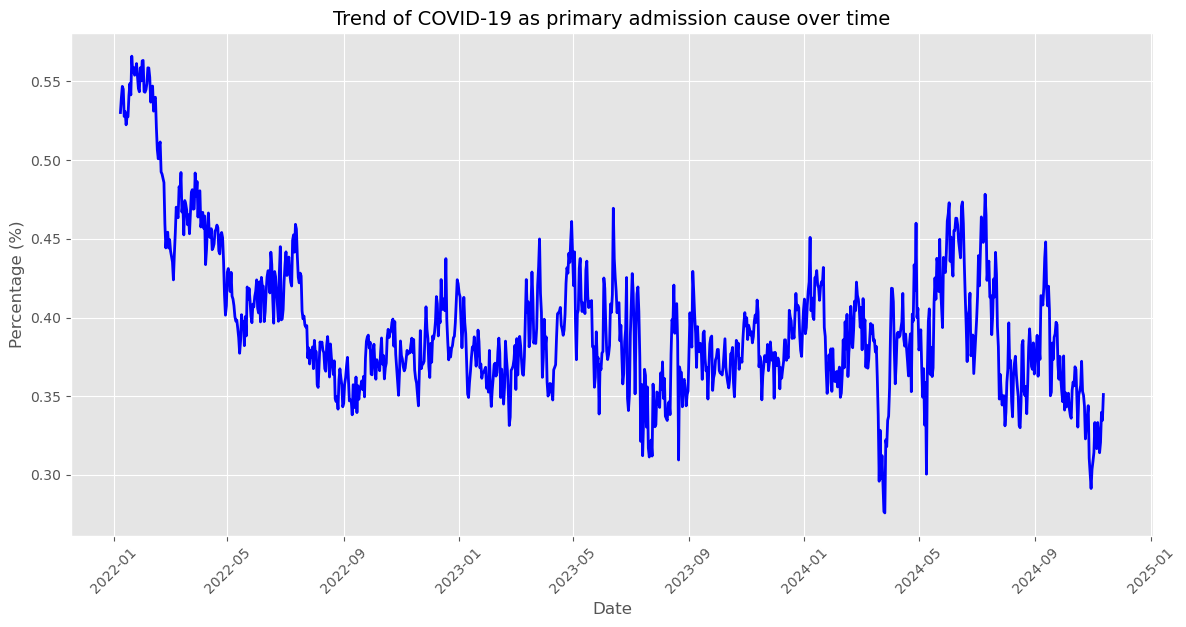

In [48]:
# Creating a visualization to show the trend of COVID-19 positive hospital admissions over time

plt.figure(figsize=(12, 6))
plt.plot(data_df['date'], data_df['hosp_for_covid'], color='blue', linewidth=2)

plt.title("Trend of COVID-19 as primary admission cause over time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.grid(True)
plt.tight_layout()

#  Rotate x-axis labels for readability
plt.xticks(rotation=45)

plt.show()


### Customizing the plot to improve readabilty and clarity for the audience 



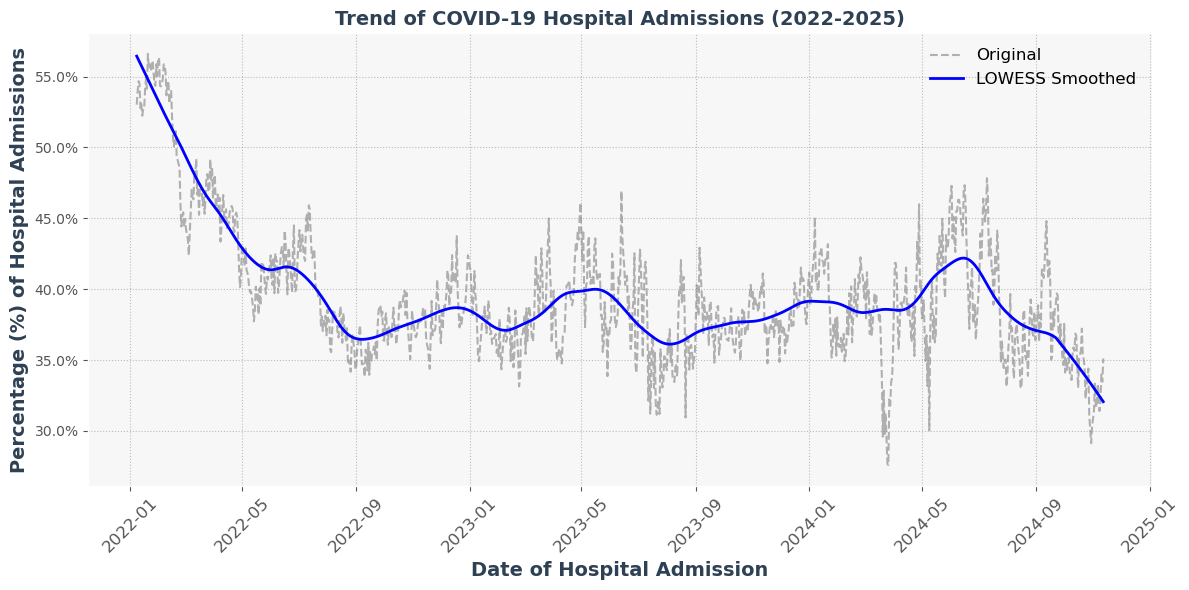

In [78]:
# Add a locally weighted scatterplot smoothing (LOWESS smoothing) to improve the visualisation of the plot
# Import LOWESS
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.dates as mdates

# Convert dates to numerical format for smoothing
date_numeric = mdates.date2num(data_df['date'])

# Apply LOWESS smoothing
lowess_result = lowess(endog=data_df['hosp_for_covid'], exog=date_numeric, frac=0.1)

# Plotting the smoothed trend
plt.figure(figsize=(12, 6))

# Original data line (light gray, dashed)
plt.plot(data_df['date'], data_df['hosp_for_covid'], label='Original', color='gray', linestyle='--', alpha=0.6)

# Smoothed line
plt.plot(mdates.num2date(lowess_result[:, 0]), lowess_result[:, 1], color='blue', linewidth=2, label='LOWESS Smoothed')

# Titles and labels
plt.title("Trend of COVID-19 Hospital Admissions (2022-2025)", fontsize=14, weight='bold', color='#2E4053') 
plt.xlabel("Date of Hospital Admission", fontsize=14, weight='bold', color='#2E4053')
plt.ylabel("Percentage (%) of Hospital Admissions", fontsize=14, weight='bold', color='#2E4053')
plt.legend()
plt.grid(True)

# Legend customization
plt.legend(loc='upper right', fontsize=12, frameon=False)

# Grid customization
plt.grid(True, linestyle=':', color='gray', alpha=0.5)

# X-axis label rotation
plt.xticks(rotation=45, fontsize=12)

# Y-axis formatting to show values from 0–100% (not decimal)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Background color
plt.gca().set_facecolor('#f7f7f7')


# Format x-axis ticks
plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure 
plt.savefig("covid_hospital_admissions_trend.png", dpi=300, bbox_inches='tight')

plt.show()

